# Results Bettable Cohort

Purpose: evaluate only the **execution cohort** (rows that pass practical support filters), separate from diagnostic stress rows.

Default cohort rules in this notebook:
- `edge >= 0.12`
- `days_rest < 45`
- `projected_tbf >= 15`
- settled + staked rows only

In [1]:
from pathlib import Path
import json
import math
import sys
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "production").exists():
    for parent in ROOT.parents:
        if (parent / "production").exists() and (parent / "src").exists():
            ROOT = parent
            break

sys.path.insert(0, str(ROOT / "src"))
from Python.exit_anomalies import apply_exit_anomaly_overrides
from Python.notebook_analysis_utils import (
    has_over_clv_red_flag,
    keep_best_available_lines,
    side_clv_roi_health,
)

LEDGER_PATH = ROOT / "artifacts" / "odds_log" / "ledger.parquet"
PROJ_PATH = ROOT / "artifacts" / "projection_log" / "projections.parquet"
POLICY_PATH = ROOT / "production" / "ops" / "kpi_policy.json"
EXIT_ANOMALY_PATH = ROOT / "production" / "ops" / "exit_anomaly_overrides.csv"

# Toggle active scope. False => all rows, True => anomaly-filtered core rows.
EXCLUDE_EXIT_ANOMALIES_FOR_PROCESS = False

# Optional local override for analysis sessions.
OPERATING_PROFILE_OVERRIDE: str | None = None

policy = json.loads(POLICY_PATH.read_text(encoding="utf-8")) if POLICY_PATH.exists() else {}
oper = policy.get("operating_profile", {}) if isinstance(policy, dict) else {}
OPERATING_PROFILE = OPERATING_PROFILE_OVERRIDE or str(oper.get("name", "A_edge12"))
REST_MAX_EXCLUSIVE = float(oper.get("filters", {}).get("rest_max_exclusive", 45.0))
TBF_MIN = float(oper.get("filters", {}).get("tbf_min", 15.0))
PROFILE_DEFS = oper.get("profiles", {}) if isinstance(oper.get("profiles", {}), dict) else {}


ledger = pl.read_parquet(LEDGER_PATH)
proj_cols = pl.read_parquet(PROJ_PATH, n_rows=1).columns if PROJ_PATH.exists() else []
proj = (
    pl.read_parquet(PROJ_PATH)
    .with_columns(pl.col("game_date").cast(pl.Utf8).str.slice(0, 10))
    .select([c for c in ["game_date", "player_name", "days_rest", "projected_tbf", "expected_K"] if c in proj_cols])
    .unique(subset=["game_date", "player_name"], keep="first")
) if PROJ_PATH.exists() else pl.DataFrame()

base_raw = ledger.filter((pl.col("status") == "settled") & (pl.col("stake").fill_null(0) > 0)).with_columns(
    pl.col("game_date").cast(pl.Utf8).str.slice(0, 10)
)
base = keep_best_available_lines(base_raw)
if proj.height:
    base = base.join(proj, on=["game_date", "player_name"], how="left")


def apply_profile(df: pl.DataFrame, profile: str) -> pl.DataFrame:
    out = df
    prof = PROFILE_DEFS.get(profile, {}) if isinstance(PROFILE_DEFS, dict) else {}
    edge_min = prof.get("edge_min")
    edge_min_over = prof.get("edge_min_over")
    edge_min_under = prof.get("edge_min_under")

    if edge_min is not None:
        out = out.filter(pl.col("edge") >= float(edge_min))
    elif edge_min_over is not None or edge_min_under is not None:
        over_thr = float(edge_min_over if edge_min_over is not None else 0.0)
        under_thr = float(edge_min_under if edge_min_under is not None else 0.0)
        out = out.filter(
            ((pl.col("side") == "over") & (pl.col("edge") >= over_thr))
            | ((pl.col("side") == "under") & (pl.col("edge") >= under_thr))
        )

    out = out.filter(
        (pl.col("days_rest").is_null() | (pl.col("days_rest") < REST_MAX_EXCLUSIVE))
        & (pl.col("projected_tbf").is_null() | (pl.col("projected_tbf") >= TBF_MIN))
    )
    return out


base_tagged = apply_exit_anomaly_overrides(base, path=EXIT_ANOMALY_PATH)
base_core = base_tagged.filter(~pl.col("exit_anomaly_flag")) if "exit_anomaly_flag" in base_tagged.columns else base_tagged
base_active = base_core if EXCLUDE_EXIT_ANOMALIES_FOR_PROCESS else base_tagged

cohort_all = apply_profile(base_tagged, OPERATING_PROFILE)
cohort_core = apply_profile(base_core, OPERATING_PROFILE)
cohort = cohort_core if EXCLUDE_EXIT_ANOMALIES_FOR_PROCESS else cohort_all

anomaly_n = int(base_tagged.filter(pl.col("exit_anomaly_flag")).height) if "exit_anomaly_flag" in base_tagged.columns else 0
print(
    f"profile={OPERATING_PROFILE} rest<{REST_MAX_EXCLUSIVE:g} tbf>={TBF_MIN:g} | "
    f"staked_raw_n={base_raw.height} best_line_base_n={base_active.height} anomaly_tagged={anomaly_n} "
    f"analysis_view={'core_ex_anomaly' if EXCLUDE_EXIT_ANOMALIES_FOR_PROCESS else 'all_rows'} cohort_n={cohort.height}"
)

side_health = side_clv_roi_health(cohort)
if side_health.height:
    print("side CLV/ROI health")
    display(side_health.to_pandas().round(3))
    if has_over_clv_red_flag(side_health):
        print("RED FLAG: over mean_clv_pp <= 0 (or missing).")

if "exit_anomaly_flag" in base_tagged.columns:
    compare = pl.concat(
        [
            apply_profile(base_tagged, OPERATING_PROFILE).with_columns(pl.lit("all_rows").alias("scope")),
            apply_profile(base_core, OPERATING_PROFILE).with_columns(pl.lit("core_ex_anomaly").alias("scope")),
        ],
        how="vertical_relaxed",
    )
    scope_health = (
        compare.group_by("scope")
        .agg(
            pl.len().alias("n"),
            pl.col("stake").sum().alias("stake"),
            pl.col("pnl").sum().alias("pnl"),
            (pl.col("pnl").sum() / pl.col("stake").sum()).alias("roi"),
            pl.col("clv_pp").mean().alias("mean_clv_pp"),
        )
        .sort("scope")
    )
    print("scope comparison")
    display(scope_health.to_pandas().round(3))


def show(df: pl.DataFrame, max_rows: int = 40):
    display(df.head(max_rows).to_pandas().round(3))
    if df.height > max_rows:
        print(f"showing first {max_rows} of {df.height} rows")

profile=D_over18_under12 rest<45 tbf>=15 | staked_raw_n=281 best_line_base_n=155 anomaly_tagged=2 analysis_view=all_rows cohort_n=93
side CLV/ROI health


,side,n,stake,pnl,roi,mean_clv_pp
0,over,23,2115.037,-353.202,-0.167,0.004
1,under,70,6059.443,875.659,0.145,0.013


scope comparison


,scope,n,stake,pnl,roi,mean_clv_pp
0,all_rows,93,8174.479,522.457,0.064,0.010
1,core_ex_anomaly,92,8045.889,409.659,0.051,0.011


In [2]:
def kpi(df: pl.DataFrame, label: str) -> pl.DataFrame:
    if df.is_empty:
        return pl.DataFrame([{"label": label, "n": 0}])
    clv_df = df.filter(pl.col("clv_pp").is_not_null())
    n_clv = clv_df.height
    beat = float((clv_df["clv_pp"] > 0).mean()) if n_clv else None
    stake = float(df["stake"].sum())
    pnl = float(df["pnl"].sum())
    exp = float((df["edge"].cast(pl.Float64) * df["stake"].cast(pl.Float64)).sum())
    return pl.DataFrame([
        {
            "label": label,
            "n": int(df.height),
            "stake": stake,
            "pnl": pnl,
            "roi": (pnl / stake) if stake > 0 else None,
            "expected_pnl": exp,
            "expected_roi": (exp / stake) if stake > 0 else None,
            "beat_clv_rate": beat,
            "n_clv": n_clv,
        }
    ])

show(pl.concat([kpi(base, "baseline_staked"), kpi(cohort, "bettable_cohort")], how="vertical_relaxed"))

print("by side (cohort)")
show(
    cohort.group_by("side").agg(
        pl.len().alias("n"),
        pl.col("stake").sum().alias("stake"),
        pl.col("pnl").sum().alias("pnl"),
        (pl.col("pnl").sum() / pl.col("stake").sum()).alias("roi"),
        ((pl.col("edge").cast(pl.Float64) * pl.col("stake").cast(pl.Float64)).sum() / pl.col("stake").sum()).alias("expected_roi"),
        (pl.col("clv_pp") > 0).mean().alias("beat_clv_rate"),
        pl.col("clv_pp").drop_nulls().len().alias("n_clv"),
    ).sort("n", descending=True)
)

print("daily trend (cohort)")
show(
    cohort.group_by("game_date").agg(
        pl.len().alias("n"),
        pl.col("stake").sum().alias("stake"),
        pl.col("pnl").sum().alias("pnl"),
        (pl.col("pnl").sum() / pl.col("stake").sum()).alias("roi"),
        ((pl.col("edge").cast(pl.Float64) * pl.col("stake").cast(pl.Float64)).sum() / pl.col("stake").sum()).alias("expected_roi"),
        (pl.col("clv_pp") > 0).mean().alias("beat_clv_rate"),
        pl.col("clv_pp").drop_nulls().len().alias("n_clv"),
    ).sort("game_date").tail(20)
)

,label,n
0,baseline_staked,0
1,bettable_cohort,0


by side (cohort)


,side,n,stake,pnl,roi,expected_roi,beat_clv_rate,n_clv
0,under,70,6059.443,875.659,0.145,0.226,0.638,47
1,over,23,2115.037,-353.202,-0.167,0.222,0.588,17


daily trend (cohort)


,game_date,n,stake,pnl,roi,expected_roi,beat_clv_rate,n_clv
0,2026-07-30,4,425.020,-193.936,-0.456,0.201,0.750,4
1,2026-07-31,5,584.319,407.900,0.698,0.256,1.000,5
2,2026-08-01,3,279.201,95.853,0.343,0.187,NaN,0
3,2026-08-02,8,957.540,-87.814,-0.092,0.227,0.375,8
4,2026-08-03,6,475.214,-232.500,-0.489,0.186,0.333,6
5,2026-08-04,7,739.527,77.025,0.104,0.219,0.429,7
6,2026-08-05,10,1170.187,652.600,0.558,0.249,0.333,3
7,2026-08-06,5,276.983,-70.251,-0.254,0.172,0.667,3
8,2026-08-07,4,205.216,-54.543,-0.266,0.166,0.500,4
9,2026-08-08,4,239.258,117.650,0.492,0.177,1.000,4


In [3]:
active_prof = PROFILE_DEFS.get(OPERATING_PROFILE, {}) if isinstance(PROFILE_DEFS, dict) else {}
active_edge_min = active_prof.get("edge_min")
active_over_min = active_prof.get("edge_min_over")
active_under_min = active_prof.get("edge_min_under")

if active_edge_min is not None:
    drop_edge_expr = pl.col("edge") < float(active_edge_min)
elif active_over_min is not None or active_under_min is not None:
    over_thr = float(active_over_min if active_over_min is not None else 0.0)
    under_thr = float(active_under_min if active_under_min is not None else 0.0)
    drop_edge_expr = (
        ((pl.col("side") == "over") & (pl.col("edge") < over_thr))
        | ((pl.col("side") == "under") & (pl.col("edge") < under_thr))
    )
else:
    drop_edge_expr = pl.lit(False)

dropped = base.with_columns([
    drop_edge_expr.alias("drop_edge"),
    (pl.col("days_rest").is_not_null() & (pl.col("days_rest") >= REST_MAX_EXCLUSIVE)).alias("drop_rest"),
    (pl.col("projected_tbf").is_not_null() & (pl.col("projected_tbf") < TBF_MIN)).alias("drop_tbf"),
]).with_columns(
    (pl.col("drop_edge") | pl.col("drop_rest") | pl.col("drop_tbf")).alias("is_dropped")
)

print("drop reason counts")
show(
    dropped.select([
        pl.len().alias("n_total"),
        pl.col("is_dropped").sum().alias("n_dropped"),
        pl.col("drop_edge").sum().alias("drop_edge"),
        pl.col("drop_rest").sum().alias("drop_rest"),
        pl.col("drop_tbf").sum().alias("drop_tbf"),
    ])
)

print("sample dropped rows")
show(
    dropped.filter(pl.col("is_dropped")).select([
        c for c in ["game_date", "player_name", "side", "edge", "days_rest", "projected_tbf", "stake", "pnl"] if c in dropped.columns
    ]).sort("game_date", descending=True).head(60)
)

drop reason counts


,n_total,n_dropped,drop_edge,drop_rest,drop_tbf
0,155,62,61,0,1


sample dropped rows


,game_date,player_name,side,edge,days_rest,projected_tbf,stake,pnl
0,2026-08-15,Brad Lord,over,0.148,6.0,21.415,43.546,-43.546
1,2026-08-14,Grayson Rodriguez,over,0.122,5.0,23.221,35.033,42.040
2,2026-08-13,Davis Martin,over,0.168,9.0,22.429,60.332,-60.332
3,2026-08-12,Zebby Matthews,over,0.164,5.0,23.674,50.497,-50.497
4,2026-08-12,Zach Thornton,over,0.122,5.0,22.934,38.734,-38.734
5,2026-08-12,Jack Perkins,over,0.155,5.0,22.768,61.783,-61.783
6,2026-08-12,Rhett Lowder,over,0.133,7.0,21.807,37.637,-37.637
7,2026-08-11,Ryan Johnson,over,0.150,5.0,22.346,43.748,57.748
8,2026-08-11,Mitch Bratt,over,0.133,6.0,20.901,38.399,-38.399
9,2026-08-10,Hunter Dobbins,over,0.134,6.0,22.467,37.955,51.619


showing first 40 of 60 rows


In [4]:
# Operating profile comparison (policy-defined + one experimental variant)
profile_names = list(PROFILE_DEFS.keys()) if isinstance(PROFILE_DEFS, dict) else []
if "C_over14_under10" not in profile_names:
    profile_names.append("C_over14_under10")  # optional research variant


def apply_profile_for_compare(df: pl.DataFrame, profile: str) -> pl.DataFrame:
    if profile == "C_over14_under10":
        out = df.filter(
            ((pl.col("side") == "over") & (pl.col("edge") >= 0.14))
            | ((pl.col("side") == "under") & (pl.col("edge") >= 0.10))
        )
        return out.filter(
            (pl.col("days_rest").is_null() | (pl.col("days_rest") < REST_MAX_EXCLUSIVE))
            & (pl.col("projected_tbf").is_null() | (pl.col("projected_tbf") >= TBF_MIN))
        )
    return apply_profile(df, profile)


rows = []
for name in profile_names:
    dfp = apply_profile_for_compare(base, name)
    if dfp.is_empty():
        rows.append({"profile": name, "is_active_profile": name == OPERATING_PROFILE, "n": 0})
        continue
    stake = float(dfp["stake"].sum())
    pnl = float(dfp["pnl"].sum())
    clv = dfp["clv_pp"].drop_nulls()
    n_clv = int(clv.len())
    beat_clv_rate = float((dfp.filter(pl.col("clv_pp").is_not_null())["clv_pp"] > 0).mean()) if n_clv else None
    expected_pnl = float((dfp["edge"].cast(pl.Float64) * dfp["stake"].cast(pl.Float64)).sum())
    rows.append(
        {
            "profile": name,
            "is_active_profile": name == OPERATING_PROFILE,
            "n": int(dfp.height),
            "stake": stake,
            "pnl": pnl,
            "roi": (pnl / stake) if stake > 0 else None,
            "expected_pnl": expected_pnl,
            "expected_roi": (expected_pnl / stake) if stake > 0 else None,
            "beat_clv_rate": beat_clv_rate,
            "n_clv": n_clv,
            "over_n": int(dfp.filter(pl.col("side") == "over").height),
            "under_n": int(dfp.filter(pl.col("side") == "under").height),
        }
    )

profile_tbl = pl.DataFrame(rows).sort("roi", descending=True)
print(f"operating profile comparison (active={OPERATING_PROFILE})")
show(profile_tbl)

operating profile comparison (active=D_over18_under12)


,profile,is_active_profile,n,stake,pnl,roi,expected_pnl,expected_roi,beat_clv_rate,n_clv,over_n,under_n
0,D_over18_under12,True,93,8174.479,522.457,0.064,1839.369,0.225,0.625,64,23,70
1,A_edge12,False,125,10079.360,184.951,0.018,2126.742,0.211,0.636,88,55,70
2,C_over14_under12,False,113,9520.256,93.907,0.010,2054.632,0.216,0.608,79,43,70
3,C_over14_under10,False,116,9663.084,49.019,0.005,2070.202,0.214,0.612,80,43,73
4,B_edge14,False,100,8860.049,-197.857,-0.022,1969.396,0.222,0.614,70,43,57


In [5]:
# CLV hit-rate confidence (Wilson interval)
def wilson_interval(k: int, n: int, z: float = 1.96) -> tuple[float | None, float | None]:
    if n <= 0:
        return None, None
    p = k / n
    denom = 1.0 + (z * z) / n
    center = (p + (z * z) / (2 * n)) / denom
    spread = (z / denom) * math.sqrt((p * (1 - p) / n) + ((z * z) / (4 * n * n)))
    return max(0.0, center - spread), min(1.0, center + spread)


if cohort.is_empty():
    print("No cohort rows for Wilson CI report.")
else:
    clv_rows = cohort.filter(pl.col("clv_pp").is_not_null())
    if clv_rows.is_empty():
        print("No CLV-tagged cohort rows yet.")
    else:
        groups = {
            "all": clv_rows,
            "over": clv_rows.filter(pl.col("side") == "over"),
            "under": clv_rows.filter(pl.col("side") == "under"),
        }
        out = []
        for name, g in groups.items():
            n = g.height
            wins = int((g["clv_pp"] > 0).sum()) if n else 0
            p = (wins / n) if n else None
            lo, hi = wilson_interval(wins, n)
            out.append(
                {
                    "slice": name,
                    "n_clv": n,
                    "n_beats": wins,
                    "beat_clv_rate": p,
                    "wilson_lo_95": lo,
                    "wilson_hi_95": hi,
                }
            )

        print("CLV beat-rate confidence (95% Wilson interval)")
        show(pl.DataFrame(out))

CLV beat-rate confidence (95% Wilson interval)


,slice,n_clv,n_beats,beat_clv_rate,wilson_lo_95,wilson_hi_95
0,all,64,40,0.625,0.503,0.733
1,over,17,10,0.588,0.360,0.784
2,under,47,30,0.638,0.495,0.760


In [6]:
# Rolling-window profile comparison (last 50 / 100 settled rows)
if base.is_empty():
    print("No base rows for rolling-window comparison.")
else:
    sort_cols = [c for c in ["logged_at_utc", "closed_at_utc", "game_date"] if c in base.columns]
    ordered = base.sort(sort_cols) if sort_cols else base

    windows = [50, 100]
    rows = []
    for w in windows:
        wsrc = ordered.tail(w)
        if wsrc.is_empty():
            continue
        for name in profile_names:
            dfp = apply_profile_for_compare(wsrc, name)
            n = dfp.height
            if n == 0:
                rows.append({"window_n": w, "profile": name, "n": 0})
                continue
            stake = float(dfp["stake"].sum())
            pnl = float(dfp["pnl"].sum())
            exp = float((dfp["edge"].cast(pl.Float64) * dfp["stake"].cast(pl.Float64)).sum())
            c = dfp.filter(pl.col("clv_pp").is_not_null())
            n_clv = c.height
            beat = float((c["clv_pp"] > 0).mean()) if n_clv else None
            rows.append(
                {
                    "window_n": w,
                    "profile": name,
                    "is_active_profile": name == OPERATING_PROFILE,
                    "n": n,
                    "roi": (pnl / stake) if stake > 0 else None,
                    "expected_roi": (exp / stake) if stake > 0 else None,
                    "beat_clv_rate": beat,
                    "n_clv": n_clv,
                }
            )

    roll_tbl = pl.DataFrame(rows).sort(["window_n", "roi"], descending=[False, True])
    print("rolling-window profile comparison")
    show(roll_tbl)

rolling-window profile comparison


,window_n,profile,is_active_profile,n,roi,expected_roi,beat_clv_rate,n_clv
0,50,D_over18_under12,True,37,-0.067,0.237,0.750,20
1,50,A_edge12,False,50,-0.096,0.221,0.793,29
2,50,C_over14_under12,False,44,-0.106,0.228,0.760,25
3,50,C_over14_under10,False,44,-0.106,0.228,0.760,25
4,50,B_edge14,False,41,-0.148,0.232,0.760,25
5,100,D_over18_under12,True,66,0.076,0.227,0.675,40
6,100,A_edge12,False,90,0.036,0.213,0.667,57
7,100,C_over14_under10,False,83,0.013,0.216,0.647,51
8,100,C_over14_under12,False,81,0.013,0.218,0.647,51
9,100,B_edge14,False,73,-0.028,0.223,0.630,46


In [7]:
# Realized vs expected deltas by side and edge bucket (active cohort)
if cohort.is_empty():
    print("No cohort rows for realized-vs-expected diagnostics.")
else:
    edge_bucketed = cohort.with_columns(
        pl.when(pl.col("edge") < 0.12).then(pl.lit("10-12%"))
        .when(pl.col("edge") < 0.14).then(pl.lit("12-14%"))
        .when(pl.col("edge") < 0.16).then(pl.lit("14-16%"))
        .otherwise(pl.lit("16%+"))
        .alias("edge_bucket")
    )

    by_side_bucket = (
        edge_bucketed.group_by(["side", "edge_bucket"])
        .agg(
            pl.len().alias("n"),
            pl.col("stake").cast(pl.Float64).sum().alias("stake"),
            pl.col("pnl").cast(pl.Float64).sum().alias("realized_pnl"),
            (pl.col("edge").cast(pl.Float64) * pl.col("stake").cast(pl.Float64)).sum().alias("expected_pnl"),
            (pl.col("clv_pp") > 0).mean().alias("beat_clv_rate"),
            pl.col("clv_pp").drop_nulls().len().alias("n_clv"),
        )
        .with_columns(
            (pl.col("realized_pnl") - pl.col("expected_pnl")).alias("pnl_delta"),
            (pl.col("realized_pnl") / pl.col("stake")).alias("realized_roi"),
            (pl.col("expected_pnl") / pl.col("stake")).alias("expected_roi"),
        )
        .sort(["side", "edge_bucket"])
    )

    print("realized vs expected by side x edge bucket")
    show(by_side_bucket)

    by_side = (
        edge_bucketed.group_by("side")
        .agg(
            pl.len().alias("n"),
            pl.col("stake").cast(pl.Float64).sum().alias("stake"),
            pl.col("pnl").cast(pl.Float64).sum().alias("realized_pnl"),
            (pl.col("edge").cast(pl.Float64) * pl.col("stake").cast(pl.Float64)).sum().alias("expected_pnl"),
            (pl.col("clv_pp") > 0).mean().alias("beat_clv_rate"),
            pl.col("clv_pp").drop_nulls().len().alias("n_clv"),
        )
        .with_columns(
            (pl.col("realized_pnl") - pl.col("expected_pnl")).alias("pnl_delta"),
            (pl.col("realized_pnl") / pl.col("stake")).alias("realized_roi"),
            (pl.col("expected_pnl") / pl.col("stake")).alias("expected_roi"),
        )
        .sort("n", descending=True)
    )

    print("\nrealized vs expected by side")
    show(by_side)

realized vs expected by side x edge bucket


,side,edge_bucket,n,stake,realized_pnl,expected_pnl,beat_clv_rate,n_clv,pnl_delta,realized_roi,expected_roi
0,over,16%+,23,2115.037,-353.202,470.562,0.588,17,-823.763,-0.167,0.222
1,under,12-14%,13,660.207,291.764,85.236,0.556,9,206.528,0.442,0.129
2,under,14-16%,11,695.536,93.772,105.164,0.714,7,-11.393,0.135,0.151
3,under,16%+,46,4703.699,490.123,1178.407,0.645,31,-688.285,0.104,0.251



realized vs expected by side


,side,n,stake,realized_pnl,expected_pnl,beat_clv_rate,n_clv,pnl_delta,realized_roi,expected_roi
0,under,70,6059.443,875.659,1368.808,0.638,47,-493.149,0.145,0.226
1,over,23,2115.037,-353.202,470.562,0.588,17,-823.763,-0.167,0.222


In [8]:
# Promotion readiness gate (PASS / HOLD)
if cohort.is_empty():
    print("No cohort rows for readiness gate.")
else:
    clv = cohort.filter(pl.col("clv_pp").is_not_null())
    n_clv = clv.height
    beat = float((clv["clv_pp"] > 0).mean()) if n_clv else None
    lo, hi = wilson_interval(int((clv["clv_pp"] > 0).sum()) if n_clv else 0, n_clv)

    stake = float(cohort["stake"].sum()) if cohort.height else 0.0
    pnl = float(cohort["pnl"].sum()) if cohort.height else 0.0
    roi = (pnl / stake) if stake > 0 else None
    exp = float((cohort["edge"].cast(pl.Float64) * cohort["stake"].cast(pl.Float64)).sum()) if cohort.height else 0.0
    exp_roi = (exp / stake) if stake > 0 else None

    checks = [
        {
            "check": "sample_size",
            "value": cohort.height,
            "rule": "n >= 150",
            "status": "PASS" if cohort.height >= 150 else "HOLD",
        },
        {
            "check": "clv_sample_size",
            "value": n_clv,
            "rule": "n_clv >= 100",
            "status": "PASS" if n_clv >= 100 else "HOLD",
        },
        {
            "check": "beat_clv_rate",
            "value": beat,
            "rule": "beat_clv_rate >= 0.50",
            "status": "PASS" if (beat is not None and beat >= 0.50) else "HOLD",
        },
        {
            "check": "beat_clv_wilson_low",
            "value": lo,
            "rule": "95% lower bound > 0.45",
            "status": "PASS" if (lo is not None and lo > 0.45) else "HOLD",
        },
        {
            "check": "realized_roi",
            "value": roi,
            "rule": "realized_roi > 0",
            "status": "PASS" if (roi is not None and roi > 0) else "HOLD",
        },
        {
            "check": "expected_roi",
            "value": exp_roi,
            "rule": "expected_roi > 0",
            "status": "PASS" if (exp_roi is not None and exp_roi > 0) else "HOLD",
        },
    ]

    readiness = pl.DataFrame(checks)
    n_hold = int(readiness.filter(pl.col("status") == "HOLD").height)
    overall = "PASS" if n_hold == 0 else "HOLD"

    print(f"promotion readiness: {overall} (holds={n_hold})")
    show(readiness)

promotion readiness: HOLD (holds=2)

,check,value,rule,status
0,sample_size,93.000,n >= 150,HOLD
1,clv_sample_size,64.000,n_clv >= 100,HOLD
2,beat_clv_rate,0.625,beat_clv_rate >= 0.50,PASS
3,beat_clv_wilson_low,0.503,95% lower bound > 0.45,PASS
4,realized_roi,0.064,realized_roi > 0,PASS
5,expected_roi,0.225,expected_roi > 0,PASS


edge-decile calibration table


,edge_decile,n,mean_edge,beat_clv_rate,n_clv,realized_roi,expected_roi
0,D1,10,0.126,0.625,8,0.588,0.127
1,D2,9,0.143,0.400,5,-0.020,0.143
2,D3,9,0.159,0.800,5,0.195,0.159
3,D4,9,0.174,0.833,6,-0.368,0.175
4,D5,10,0.190,0.500,6,-0.806,0.190
5,D6,9,0.203,0.714,7,0.037,0.203
6,D7,9,0.215,0.571,7,0.188,0.215
7,D8,9,0.237,0.500,6,0.354,0.237
8,D9,9,0.262,0.429,7,-0.292,0.263
9,D10,10,0.335,0.857,7,0.467,0.340


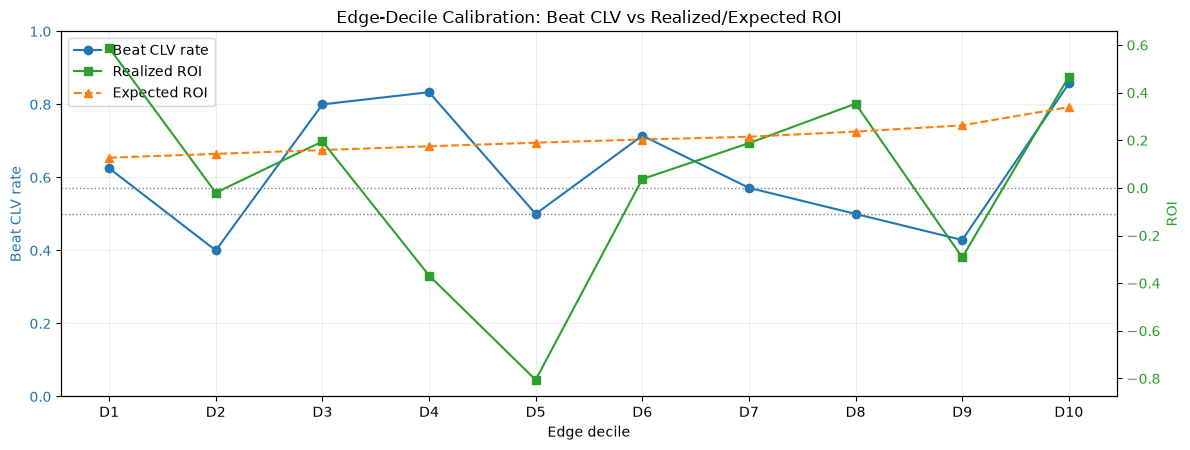

In [9]:
# Calibration curve by edge decile (active cohort)
if cohort.is_empty():
    print("No cohort rows for edge-decile calibration view.")
else:
    src = cohort.filter(pl.col("edge").is_not_null())
    if src.height < 40:
        print("Not enough rows for stable edge-decile view (need ~40+).")
    else:
        try:
            dec = src.with_columns(
                pl.col("edge").qcut(10, labels=[f"D{i}" for i in range(1, 11)], allow_duplicates=True).alias("edge_decile")
            )
        except Exception:
            dec = src.with_columns(
                pl.col("edge").qcut(5, labels=[f"Q{i}" for i in range(1, 6)], allow_duplicates=True).alias("edge_decile")
            )

        curve = (
            dec.group_by("edge_decile")
            .agg(
                pl.len().alias("n"),
                pl.col("edge").mean().alias("mean_edge"),
                (pl.col("clv_pp") > 0).mean().alias("beat_clv_rate"),
                pl.col("clv_pp").drop_nulls().len().alias("n_clv"),
                (pl.col("pnl").cast(pl.Float64).sum() / pl.col("stake").cast(pl.Float64).sum()).alias("realized_roi"),
                ((pl.col("edge").cast(pl.Float64) * pl.col("stake").cast(pl.Float64)).sum() / pl.col("stake").cast(pl.Float64).sum()).alias("expected_roi"),
            )
            .sort("mean_edge")
        )

        print("edge-decile calibration table")
        show(curve)

        pdf = curve.to_pandas()
        x = range(len(pdf))
        labels = pdf["edge_decile"].tolist()

        fig, ax1 = plt.subplots(figsize=(12, 4.6))
        ax1.plot(x, pdf["beat_clv_rate"], marker="o", color="#1f77b4", label="Beat CLV rate")
        ax1.axhline(0.5, color="gray", linestyle=":", linewidth=1)
        ax1.set_ylabel("Beat CLV rate", color="#1f77b4")
        ax1.set_ylim(0, 1)
        ax1.tick_params(axis="y", labelcolor="#1f77b4")
        ax1.set_xticks(list(x))
        ax1.set_xticklabels(labels, rotation=0)
        ax1.set_xlabel("Edge decile")
        ax1.grid(alpha=0.2)

        ax2 = ax1.twinx()
        ax2.plot(x, pdf["realized_roi"], marker="s", color="#2ca02c", label="Realized ROI")
        ax2.plot(x, pdf["expected_roi"], marker="^", color="#ff7f0e", linestyle="--", label="Expected ROI")
        ax2.axhline(0.0, color="gray", linestyle=":", linewidth=1)
        ax2.set_ylabel("ROI", color="#2ca02c")
        ax2.tick_params(axis="y", labelcolor="#2ca02c")

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
        plt.title("Edge-Decile Calibration: Beat CLV vs Realized/Expected ROI")
        plt.tight_layout()
        plt.show()

In [10]:
# Bayesian profile decision support (Beta-Binomial on CLV beat rate)
if base.is_empty():
    print("No base rows for Bayesian profile comparison.")
else:
    rng = np.random.default_rng(42)
    draws_n = 120_000

    profile_post = {}
    for name in profile_names:
        dfp = apply_profile_for_compare(base, name)
        clv = dfp.filter(pl.col("clv_pp").is_not_null())
        n = clv.height
        wins = int((clv["clv_pp"] > 0).sum()) if n else 0
        # Uniform Beta(1,1) prior + Binomial data -> Beta posterior.
        a = 1 + wins
        b = 1 + (n - wins)
        samples = rng.beta(a, b, size=draws_n)
        profile_post[name] = {
            "n_clv": n,
            "wins": wins,
            "post_mean": float(samples.mean()),
            "post_p05": float(np.quantile(samples, 0.05)),
            "post_p95": float(np.quantile(samples, 0.95)),
            "samples": samples,
        }

    summary_rows = []
    for name, d in profile_post.items():
        summary_rows.append(
            {
                "profile": name,
                "is_active_profile": name == OPERATING_PROFILE,
                "n_clv": d["n_clv"],
                "n_beats": d["wins"],
                "posterior_mean_beat_clv": d["post_mean"],
                "posterior_p05": d["post_p05"],
                "posterior_p95": d["post_p95"],
            }
        )

    post_tbl = pl.DataFrame(summary_rows).sort("posterior_mean_beat_clv", descending=True)
    print("Bayesian posterior summary: beat-CLV rate by profile")
    show(post_tbl)

    # Pairwise decision against active profile.
    if OPERATING_PROFILE in profile_post:
        act = profile_post[OPERATING_PROFILE]["samples"]
        pair_rows = []
        for name, d in profile_post.items():
            if name == OPERATING_PROFILE:
                continue
            alt = d["samples"]
            p_alt_better = float((alt > act).mean())
            p_act_better = float((act > alt).mean())
            # Expected decision regret on beat-rate scale.
            regret_choose_active = float(np.maximum(alt - act, 0).mean())
            regret_choose_alt = float(np.maximum(act - alt, 0).mean())
            pair_rows.append(
                {
                    "active_profile": OPERATING_PROFILE,
                    "alternative": name,
                    "P(alternative > active)": p_alt_better,
                    "P(active > alternative)": p_act_better,
                    "expected_regret_choose_active": regret_choose_active,
                    "expected_regret_choose_alternative": regret_choose_alt,
                }
            )

        pair_tbl = pl.DataFrame(pair_rows).sort("P(alternative > active)", descending=True)
        print("\nPairwise Bayesian decision table vs active profile")
        show(pair_tbl)
    else:
        print(f"Active profile {OPERATING_PROFILE} not found in profile set.")

Bayesian posterior summary: beat-CLV rate by profile


,profile,is_active_profile,n_clv,n_beats,posterior_mean_beat_clv,posterior_p05,posterior_p95
0,A_edge12,False,88,56,0.633,0.549,0.715
1,D_over18_under12,True,64,40,0.621,0.521,0.717
2,B_edge14,False,70,43,0.611,0.515,0.704
3,C_over14_under10,False,80,49,0.610,0.520,0.697
4,C_over14_under12,False,79,48,0.605,0.514,0.692



Pairwise Bayesian decision table vs active profile


,active_profile,alternative,P(alternative > active),P(active > alternative),expected_regret_choose_active,expected_regret_choose_alternative
0,D_over18_under12,A_edge12,0.561,0.439,0.037,0.025
1,D_over18_under12,B_edge14,0.451,0.549,0.028,0.038
2,D_over18_under12,C_over14_under10,0.442,0.558,0.027,0.038
3,D_over18_under12,C_over14_under12,0.419,0.581,0.025,0.041
